# Rolling backtest: porównanie modeli tabelowych

Ten notebook porównuje dwa aktualne modele tabelowe na wielu sezonach testowych:

- `table_static.stan` - statyczny skill drużyny,
- `table_hierarchical.stan` - trwały skill drużyny + sezonowe odchylenie.

Rolling backtest odpowiada na pytanie: czy model działa powtarzalnie, czy tylko dobrze wygląda na jednym sezonie testowym.

Dla każdego sezonu testowego robimy:

```text
train: wszystkie sezony przed sezonem testowym
test: jeden kolejny sezon
features: informacje znane przed testem, czyli ostatni sezon treningowy
```

To jest uczciwy setup bez przecieku informacji z sezonu testowego.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    predict_table,
    compute_table,
    teams_in_season,
    STUDENT_T_NU,
    ALL_TRAIN_SEASONS,
)

matches = load_matches()
all_seasons = ALL_TRAIN_SEASONS
print(all_seasons)

['0910', '1011', '1112', '1213', '1314', '1415', '1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425', '2526']


## Konfiguracja

Domyślnie testujemy kilka ostatnich sezonów, ale można rozszerzyć listę `TEST_SEASONS`. Im więcej sezonów i próbek, tym lepsze porównanie, ale dłuższy czas liczenia.

Ważne: dla sezonu testowego `s` trenujemy wyłącznie na sezonach wcześniejszych niż `s`.

In [2]:
# Sensowny kompromis czas/jakość. Do finalnego raportu można podnieść sampling.
TEST_SEASONS = ["1819", "1920", "2021", "2122", "2223", "2324", "2425", "2526"]

ITER_WARMUP_STATIC = 800
ITER_SAMPLING_STATIC = 800
ITER_WARMUP_HIER = 1000
ITER_SAMPLING_HIER = 1000
N_TABLE_SIMS = 600

ADAPT_DELTA = 0.99
CHAINS = 4
PARALLEL_CHAINS = 4

## Funkcje pomocnicze

`run_one_backtest` trenuje oba modele dla jednego sezonu testowego i zwraca predykcje drużyn oraz metryki błędu.

Metryki:

- `mae_pos` - średni błąd bezwzględny pozycji,
- `mae_pts` - średni błąd bezwzględny punktów,
- `spearman_pos` - korelacja rangowa między przewidywaną i rzeczywistą pozycją.

`mae_pos` jest najbardziej intuicyjne dla tabeli. `mae_pts` mówi, czy model dobrze kalibruje punkty.

In [3]:
def evaluate_prediction(pred: pd.DataFrame, actual: pd.DataFrame, *, model_name: str, test_season: str) -> tuple[pd.DataFrame, dict]:
    out = pred.merge(actual, on="team", how="left")
    out["model"] = model_name
    out["test_season"] = test_season
    out["pos_error"] = out["pos_median"] - out["pos_actual"]
    out["pts_error"] = out["pts_median"] - out["pts_actual"]

    metrics = {
        "model": model_name,
        "test_season": test_season,
        "mae_pos": float(out["pos_error"].abs().mean()),
        "mae_pts": float(out["pts_error"].abs().mean()),
        "spearman_pos": float(out[["pos_median", "pos_actual"]].corr(method="spearman").iloc[0, 1]),
    }
    return out, metrics


def promoted_teams_for_test(matches: pd.DataFrame, test_season: str, train_seasons: list[str]) -> set[str]:
    test_teams = teams_in_season(matches, test_season)
    last_train_teams = teams_in_season(matches, train_seasons[-1])
    return set(test_teams) - set(last_train_teams)


def run_one_backtest(test_season: str, seed_offset: int = 0) -> tuple[pd.DataFrame, pd.DataFrame]:
    test_idx = all_seasons.index(test_season)
    train_seasons = all_seasons[:test_idx]
    last_train_season = train_seasons[-1]
    test_teams = sorted(teams_in_season(matches, test_season))

    print(f"\n=== Test season {test_season}; train through {last_train_season} ===")
    print(f"Promoted/new vs last PL season: {sorted(promoted_teams_for_test(matches, test_season, train_seasons))}")

    tables = load_season_tables(matches, train_seasons)
    actual = compute_table(matches, test_season)[["team", "position", "Pts"]]
    actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

    # Model 1: static table model
    stan1, team_to_idx1, _, feature_stats1 = prepare_table_stan_static(tables, train_seasons)
    stan1["nu"] = STUDENT_T_NU
    model1 = CmdStanModel(stan_file="stan/table_static.stan")
    fit1 = model1.sample(
        data=stan1,
        seed=1000 + seed_offset,
        chains=CHAINS,
        parallel_chains=PARALLEL_CHAINS,
        iter_warmup=ITER_WARMUP_STATIC,
        iter_sampling=ITER_SAMPLING_STATIC,
        adapt_delta=ADAPT_DELTA,
        show_progress=False,
    )
    feat1 = build_forecast_features(matches, last_train_season, test_teams, train_seasons, feature_stats1)
    pred1 = predict_table(
        fit1,
        test_teams,
        team_to_idx1,
        model="static",
        team_features=feat1,
        n_sims=N_TABLE_SIMS,
        seed=2000 + seed_offset,
    )

    # Model 2: hierarchical table model
    stan2, team_to_idx2, _, season_to_idx2, feature_stats2 = prepare_table_stan_hierarchical(tables, train_seasons)
    stan2["nu"] = STUDENT_T_NU
    last_season_idx = season_to_idx2[last_train_season]
    model2 = CmdStanModel(stan_file="stan/table_hierarchical.stan")
    fit2 = model2.sample(
        data=stan2,
        seed=3000 + seed_offset,
        chains=CHAINS,
        parallel_chains=PARALLEL_CHAINS,
        iter_warmup=ITER_WARMUP_HIER,
        iter_sampling=ITER_SAMPLING_HIER,
        adapt_delta=ADAPT_DELTA,
        show_progress=False,
    )
    feat2 = build_forecast_features(matches, last_train_season, test_teams, train_seasons, feature_stats2)
    pred2 = predict_table(
        fit2,
        test_teams,
        team_to_idx2,
        model="hierarchical",
        last_season_index=last_season_idx,
        team_features=feat2,
        n_sims=N_TABLE_SIMS,
        seed=4000 + seed_offset,
    )

    rows = []
    metrics = []
    for pred, name in [(pred1, "static"), (pred2, "hierarchical")]:
        evaluated, metric = evaluate_prediction(pred, actual, model_name=name, test_season=test_season)
        rows.append(evaluated)
        metrics.append(metric)

    return pd.concat(rows, ignore_index=True), pd.DataFrame(metrics)

## Uruchomienie rolling backtestu

Ta komórka może liczyć kilka minut, bo dla każdego sezonu trenuje oba modele. Jeśli chcesz szybciej sprawdzić pipeline, ustaw krótszą listę `TEST_SEASONS`, np. `['2324', '2425', '2526']`.

In [4]:
all_predictions = []
all_metrics = []

for i, season in enumerate(TEST_SEASONS):
    preds, metrics = run_one_backtest(season, seed_offset=i)
    all_predictions.append(preds)
    all_metrics.append(metrics)

predictions = pd.concat(all_predictions, ignore_index=True)
metrics = pd.concat(all_metrics, ignore_index=True)

metrics


=== Test season 1819; train through 1718 ===
Promoted/new vs last PL season: ['Cardiff', 'Fulham', 'Wolves']


16:06:00 - cmdstanpy - INFO - CmdStan start processing
16:06:00 - cmdstanpy - INFO - Chain [1] start processing
16:06:00 - cmdstanpy - INFO - Chain [2] start processing
16:06:00 - cmdstanpy - INFO - Chain [3] start processing
16:06:00 - cmdstanpy - INFO - Chain [4] start processing
16:06:01 - cmdstanpy - INFO - Chain [1] done processing
16:06:01 - cmdstanpy - INFO - Chain [4] done processing
16:06:02 - cmdstanpy - INFO - Chain [3] done processing
16:06:02 - cmdstanpy - INFO - Chain [2] done processing
16:06:02 - cmdstanpy - INFO - CmdStan start processing
16:06:02 - cmdstanpy - INFO - Chain [1] start processing
16:06:02 - cmdstanpy - INFO - Chain [2] start processing
16:06:02 - cmdstanpy - INFO - Chain [3] start processing
16:06:02 - cmdstanpy - INFO - Chain [4] start processing
16:06:05 - cmdstanpy - INFO - Chain [2] done processing
16:06:05 - cmdstanpy - INFO - Chain [1] done processing
16:06:05 - cmdstanpy - INFO - Chain [4] done processing
16:06:05 - cmdstanpy - INFO - Chain [3] do


=== Test season 1920; train through 1819 ===
Promoted/new vs last PL season: ['Aston Villa', 'Norwich', 'Sheffield United']


16:06:07 - cmdstanpy - INFO - Chain [3] done processing
16:06:07 - cmdstanpy - INFO - Chain [1] done processing
16:06:08 - cmdstanpy - INFO - Chain [4] done processing
16:06:08 - cmdstanpy - INFO - Chain [2] done processing
16:06:08 - cmdstanpy - INFO - CmdStan start processing
16:06:08 - cmdstanpy - INFO - Chain [1] start processing
16:06:08 - cmdstanpy - INFO - Chain [2] start processing
16:06:08 - cmdstanpy - INFO - Chain [3] start processing
16:06:08 - cmdstanpy - INFO - Chain [4] start processing
16:06:10 - cmdstanpy - INFO - Chain [4] done processing
16:06:10 - cmdstanpy - INFO - Chain [2] done processing
16:06:10 - cmdstanpy - INFO - Chain [1] done processing
16:06:11 - cmdstanpy - INFO - Chain [3] done processing
16:06:12 - cmdstanpy - INFO - CmdStan start processing
16:06:12 - cmdstanpy - INFO - Chain [1] start processing
16:06:12 - cmdstanpy - INFO - Chain [2] start processing
16:06:12 - cmdstanpy - INFO - Chain [3] start processing
16:06:12 - cmdstanpy - INFO - Chain [4] sta


=== Test season 2021; train through 1920 ===
Promoted/new vs last PL season: ['Fulham', 'Leeds', 'West Brom']


...


=== Test season 2425; train through 2324 ===
Promoted/new vs last PL season: ['Ipswich', 'Leicester', 'Southampton']


16:06:41 - cmdstanpy - INFO - CmdStan start processing
16:06:41 - cmdstanpy - INFO - Chain [1] start processing
16:06:41 - cmdstanpy - INFO - Chain [2] start processing
16:06:41 - cmdstanpy - INFO - Chain [3] start processing
16:06:41 - cmdstanpy - INFO - Chain [4] start processing
16:06:43 - cmdstanpy - INFO - Chain [1] done processing
16:06:44 - cmdstanpy - INFO - Chain [3] done processing
16:06:44 - cmdstanpy - INFO - Chain [4] done processing
16:06:44 - cmdstanpy - INFO - Chain [2] done processing
16:06:44 - cmdstanpy - INFO - CmdStan start processing
16:06:44 - cmdstanpy - INFO - Chain [1] start processing
16:06:44 - cmdstanpy - INFO - Chain [2] start processing
16:06:44 - cmdstanpy - INFO - Chain [3] start processing
16:06:44 - cmdstanpy - INFO - Chain [4] start processing
16:06:49 - cmdstanpy - INFO - Chain [1] done processing
16:06:49 - cmdstanpy - INFO - Chain [4] done processing
16:06:49 - cmdstanpy - INFO - Chain [3] done processing
16:06:49 - cmdstanpy - INFO - Chain [2] do


=== Test season 2526; train through 2425 ===
Promoted/new vs last PL season: ['Burnley', 'Leeds', 'Sunderland']


16:06:50 - cmdstanpy - INFO - CmdStan start processing
16:06:50 - cmdstanpy - INFO - Chain [1] start processing
16:06:50 - cmdstanpy - INFO - Chain [2] start processing
16:06:50 - cmdstanpy - INFO - Chain [3] start processing
16:06:50 - cmdstanpy - INFO - Chain [4] start processing
16:06:52 - cmdstanpy - INFO - Chain [4] done processing
16:06:53 - cmdstanpy - INFO - Chain [3] done processing
16:06:53 - cmdstanpy - INFO - Chain [2] done processing
16:06:53 - cmdstanpy - INFO - Chain [1] done processing
16:06:54 - cmdstanpy - INFO - CmdStan start processing
16:06:54 - cmdstanpy - INFO - Chain [1] start processing
16:06:54 - cmdstanpy - INFO - Chain [2] start processing
16:06:54 - cmdstanpy - INFO - Chain [3] start processing
16:06:54 - cmdstanpy - INFO - Chain [4] start processing
16:06:58 - cmdstanpy - INFO - Chain [1] done processing
16:06:59 - cmdstanpy - INFO - Chain [3] done processing
16:06:59 - cmdstanpy - INFO - Chain [2] done processing
16:06:59 - cmdstanpy - INFO - Chain [4] do

,model,test_season,mae_pos,mae_pts,spearman_pos
0,static,1819,2.400,8.097461,0.778810
1,hierarchical,1819,2.475,8.416638,0.753601
2,static,1920,2.875,9.192391,0.706891
3,hierarchical,1920,2.850,8.884088,0.773547
4,static,2021,2.775,8.120290,0.743120
5,hierarchical,2021,2.650,7.966377,0.764999
6,static,2122,2.850,9.171716,0.811973
7,hierarchical,2122,2.675,9.288227,0.811019
8,static,2223,3.950,11.620197,0.531023
9,hierarchical,2223,4.000,11.737357,0.499633


## Podsumowanie wyników

Patrzymy na średnie metryki po sezonach. Niższe `mae_pos` i `mae_pts` są lepsze. Wyższe `spearman_pos` jest lepsze.

In [5]:
summary = (
    metrics
    .groupby("model")[["mae_pos", "mae_pts", "spearman_pos"]]
    .agg(["mean", "std"])
    .round(3)
)
summary

mae_pos        mae_pts        spearman_pos       
                mean    std    mean    std         mean    std
model                                                         
hierarchical   3.091  0.591   9.688  1.567        0.714  0.107
static         3.128  0.576   9.728  1.588        0.711  0.095

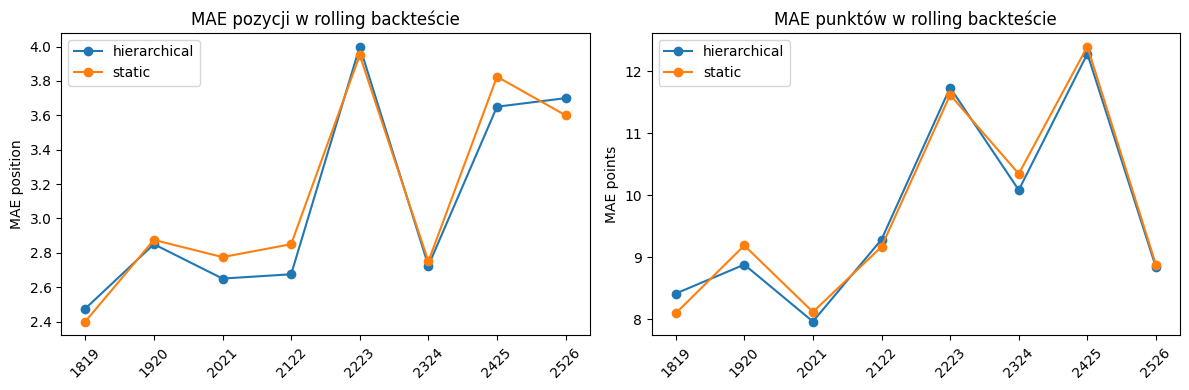

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model, group in metrics.groupby("model"):
    axes[0].plot(group["test_season"], group["mae_pos"], marker="o", label=model)
    axes[1].plot(group["test_season"], group["mae_pts"], marker="o", label=model)

axes[0].set_title("MAE pozycji w rolling backteście")
axes[0].set_ylabel("MAE position")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].set_title("MAE punktów w rolling backteście")
axes[1].set_ylabel("MAE points")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## Agreement między modelami

Jeśli modele bardzo się zgadzają, to nie musi oznaczać przecieku. Oba modele widzą te same lagowane cechy i oba mają komponent trwałej jakości drużyny. Model hierarchiczny ma dodatkowy sezonowy składnik, ale jest on shrinkowany. W forecastach losujemy nowy sezonowy składnik z `tau_season`, zamiast kopiować szok z ostatniego sezonu treningowego.

Poniższy wykres pokazuje zgodność median pozycji w sezonach testowych.

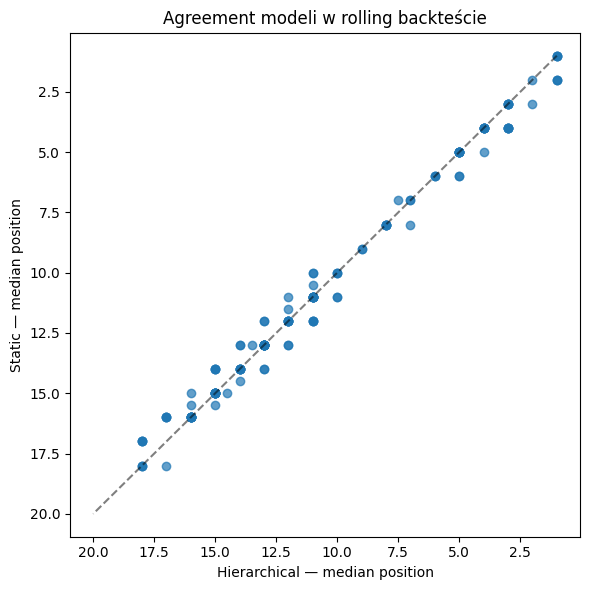

Spearman między modelami: 0.992


In [7]:
wide = predictions.pivot_table(
    index=["test_season", "team"],
    columns="model",
    values="pos_median",
).reset_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(wide["hierarchical"], wide["static"], alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Hierarchical — median position")
ax.set_ylabel("Static — median position")
ax.set_title("Agreement modeli w rolling backteście")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Spearman między modelami:", wide[["hierarchical", "static"]].corr(method="spearman").iloc[0, 1].round(3))

## Beniaminkowie: o co chodzi?

Beniaminkowie są trudni dla modelu tabelowego, bo w poprzednim sezonie nie grali w Premier League. To oznacza, że dla nich często brakuje:

- `sot_diff_pg` z poprzedniego sezonu Premier League,
- `ppg_last10` z poprzedniego sezonu Premier League,
- historycznego skilla w modelu, jeśli drużyna nie występowała wcześniej w danych treningowych.

Wcześniej projekt traktował takie drużyny neutralnie:

```text
brak cech -> średnia treningowa, czyli 0 po standaryzacji
brak skilla -> 0, czyli drużyna przeciętna
```

To jest proste i bezpieczne technicznie, ale sportowo może być zbyt optymistyczne. Beniaminkowie zwykle są słabsi niż przeciętna drużyna Premier League. Jeśli dostają neutralny skill, model może zawyżać ich przewidywane punkty i pozycje.

Aktualne ulepszenie w modelach:

```stan
beta_promoted ~ normal(-10, 5);
mu += beta_promoted * is_promoted;
```

Wtedy model dostaje jawny sygnał, że drużyna jest beniaminkiem. Prior `normal(-10, 5)` oznaczałby: przed zobaczeniem danych zakładamy, że beniaminek ma przeciętnie około 10 punktów mniej niż porównywalna drużyna bez tej flagi, ale pozwalamy danym to skorygować.

W projekcie `is_promoted` jest dodawane do danych treningowych i forecastowych: drużyna jest beniaminkiem, jeśli nie grała w Premier League w poprzednim sezonie.

In [8]:
promoted_rows = []
for season in TEST_SEASONS:
    idx = all_seasons.index(season)
    train_seasons = all_seasons[:idx]
    for team in sorted(promoted_teams_for_test(matches, season, train_seasons)):
        promoted_rows.append({"test_season": season, "team": team})

pd.DataFrame(promoted_rows)

,test_season,team
0,1819,Cardiff
1,1819,Fulham
2,1819,Wolves
3,1920,Aston Villa
4,1920,Norwich
5,1920,Sheffield United
6,2021,Fulham
7,2021,Leeds
8,2021,West Brom
9,2122,Brentford
